In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')
df

,model,tahun,harga,transmisi,odometer,jenis,pajak,konsumsiBBM,mesin
0,Supra X 125,2017,7999,Manual,17307,Bebek,145.0,58.9,125.0
1,Vario 125,2016,14499,Automatic,25233,Skuter,235.0,43.5,125.0
2,Vario 125,2016,11399,Automatic,37877,Skuter,30.0,61.7,125.0
3,Revo,2016,6499,Manual,23789,Bebek,20.0,60.1,110.0
4,PCX,2015,10199,Automatic,33177,Skuter,160.0,51.4,150.0
...,...,...,...,...,...,...,...,...,...
194,Vario 125,2019,15998,Automatic,17841,Skuter,150.0,34.9,125.0
195,Genio,2015,8798,Automatic,21701,Skuter,150.0,48.7,110.0
196,Vario 125,2019,15498,Automatic,15751,Sport,150.0,34.9,125.0
197,Supra X 125,2016,8298,Manual,17499,Bebek,30.0,55.4,125.0


In [ ]:
import pandas as pd

df = pd.read_csv('/content/motor_second.csv', sep=';')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   model        199 non-null    object 
 1   tahun        199 non-null    int64  
 2   harga        199 non-null    int64  
 3   transmisi    199 non-null    object 
 4   odometer     199 non-null    int64  
 5   jenis        199 non-null    object 
 6   pajak        199 non-null    float64
 7   konsumsiBBM  199 non-null    float64
 8   mesin        198 non-null    float64
dtypes: float64(3), int64(3), object(3)
memory usage: 14.1+ KB


In [ ]:
df.shape

(199, 9)

In [ ]:
highest_10_individual_prices = df.sort_values(by='harga', ascending=False).head(10)

print("Top 10 individual motorcycles with the highest prices:")
display(highest_10_individual_prices[['model', 'transmisi', 'jenis', 'harga']])

Top 10 individual motorcycles with the highest prices:


,model,transmisi,jenis,harga
170,CRF 150,Kopling,Trail,34998
171,CRF 150,Kopling,Trail,34998
168,Genio,Automatic,Skuter,23498
158,Verza,Kopling,Sport,21998
149,Sonic 150,Kopling,Bebek,19998
74,CB150R,Kopling,Sport,19800
129,CRF 150,Kopling,Trail,18999
175,Vario 125,Automatic,Skuter,18998
187,Vario 125,Automatic,Skuter,18698
65,Sonic 150,Kopling,Bebek,18500


In [ ]:
display(lowest_10_individual_prices[['model', 'transmisi', 'jenis', 'harga']])

,model,transmisi,jenis,harga
130,Revo,Manual,Bebek,3799
45,Revo,Manual,Bebek,5000
96,PCX,Automatic,Skuter,5000
140,Revo,Manual,Bebek,5498
68,Revo,Manual,Bebek,5500
92,Revo,Manual,Bebek,5644
162,Revo,Manual,Bebek,5998
137,Revo,Manual,Bebek,5998
182,BeAT Street,Automatic,Skuter,5998
99,Revo,Manual,Bebek,6000


In [ ]:
df["jenis"].value_counts()

,count
jenis,
Skuter,107
Bebek,75
Sport,11
Trail,6


In [ ]:
df["transmisi"].value_counts()

,count
transmisi,
Automatic,107
Manual,65
Kopling,27


In [ ]:
df["model"].value_counts()

,count
model,
Vario 125,63
Revo,40
Supra X 125,24
Genio,24
PCX,11
Verza,8
BeAT Street,8
Sonic 150,6
CRF 150,6


In [ ]:
df.isnull().sum() #melihat missing value

#nilai 0 menandakan tidak ada missing value

,0
model,0
tahun,0
harga,0
transmisi,0
odometer,0
jenis,0
pajak,0
konsumsiBBM,0
mesin,1


In [ ]:
df[df.isnull().any(axis=1)]

,model,tahun,harga,transmisi,odometer,jenis,pajak,konsumsiBBM,mesin
183,Vario 125,2018,16500,Automatic,12875,Skuter,38.7,125.0,NaN


In [ ]:
rata_harga_model = (
    df.groupby('model')['harga']
    .mean()
    .reset_index()
    .sort_values(by='harga', ascending=False)
)

# Mengubah nama kolom
rata_harga_model.columns = ['model Motor', 'Harga Rata-rata']

print(rata_harga_model)

     model Motor  Harga Rata-rata
4        CRF 150     22915.166667
3         CB150R     17400.000000
8      Sonic 150     16465.666667
12         Verza     15409.750000
11     Vario 125     14230.301587
5          Genio     10815.166667
9      Supra GTR     10319.200000
10   Supra X 125      8943.791667
6            PCX      8593.363636
1          BeAT       8300.000000
2    BeAT Street      7185.750000
7           Revo      7058.050000
0           BeAT      6300.000000


In [ ]:
import pandas as pd

# Membaca file CSV
df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')

# Menghitung rata-rata harga per jenis motor
rata_harga_jenis = (
    df.groupby('jenis')['harga']
    .mean()
    .reset_index()
    .sort_values(by='harga', ascending=False)
)

# Mengubah nama kolom
rata_harga_jenis.columns = ['Jenis Motor', 'Harga Rata-rata']

print(rata_harga_jenis)

  Jenis Motor  Harga Rata-rata
3       Trail     22915.166667
2       Sport     15779.636364
1      Skuter     12263.439252
0       Bebek      8564.840000


In [ ]:
rata_harga_transmisi = (
    df.groupby('transmisi')['harga']
    .mean()
    .reset_index()
    .sort_values(by='harga', ascending=False)
)

# Mengubah nama kolom
rata_harga_transmisi.columns = ['Transmisi Motor', 'Harga Rata-rata']

print(rata_harga_transmisi)

  Transmisi Motor  Harga Rata-rata
1         Kopling     16517.000000
0       Automatic     12300.803738
2          Manual      7745.738462


**Scatterplot**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


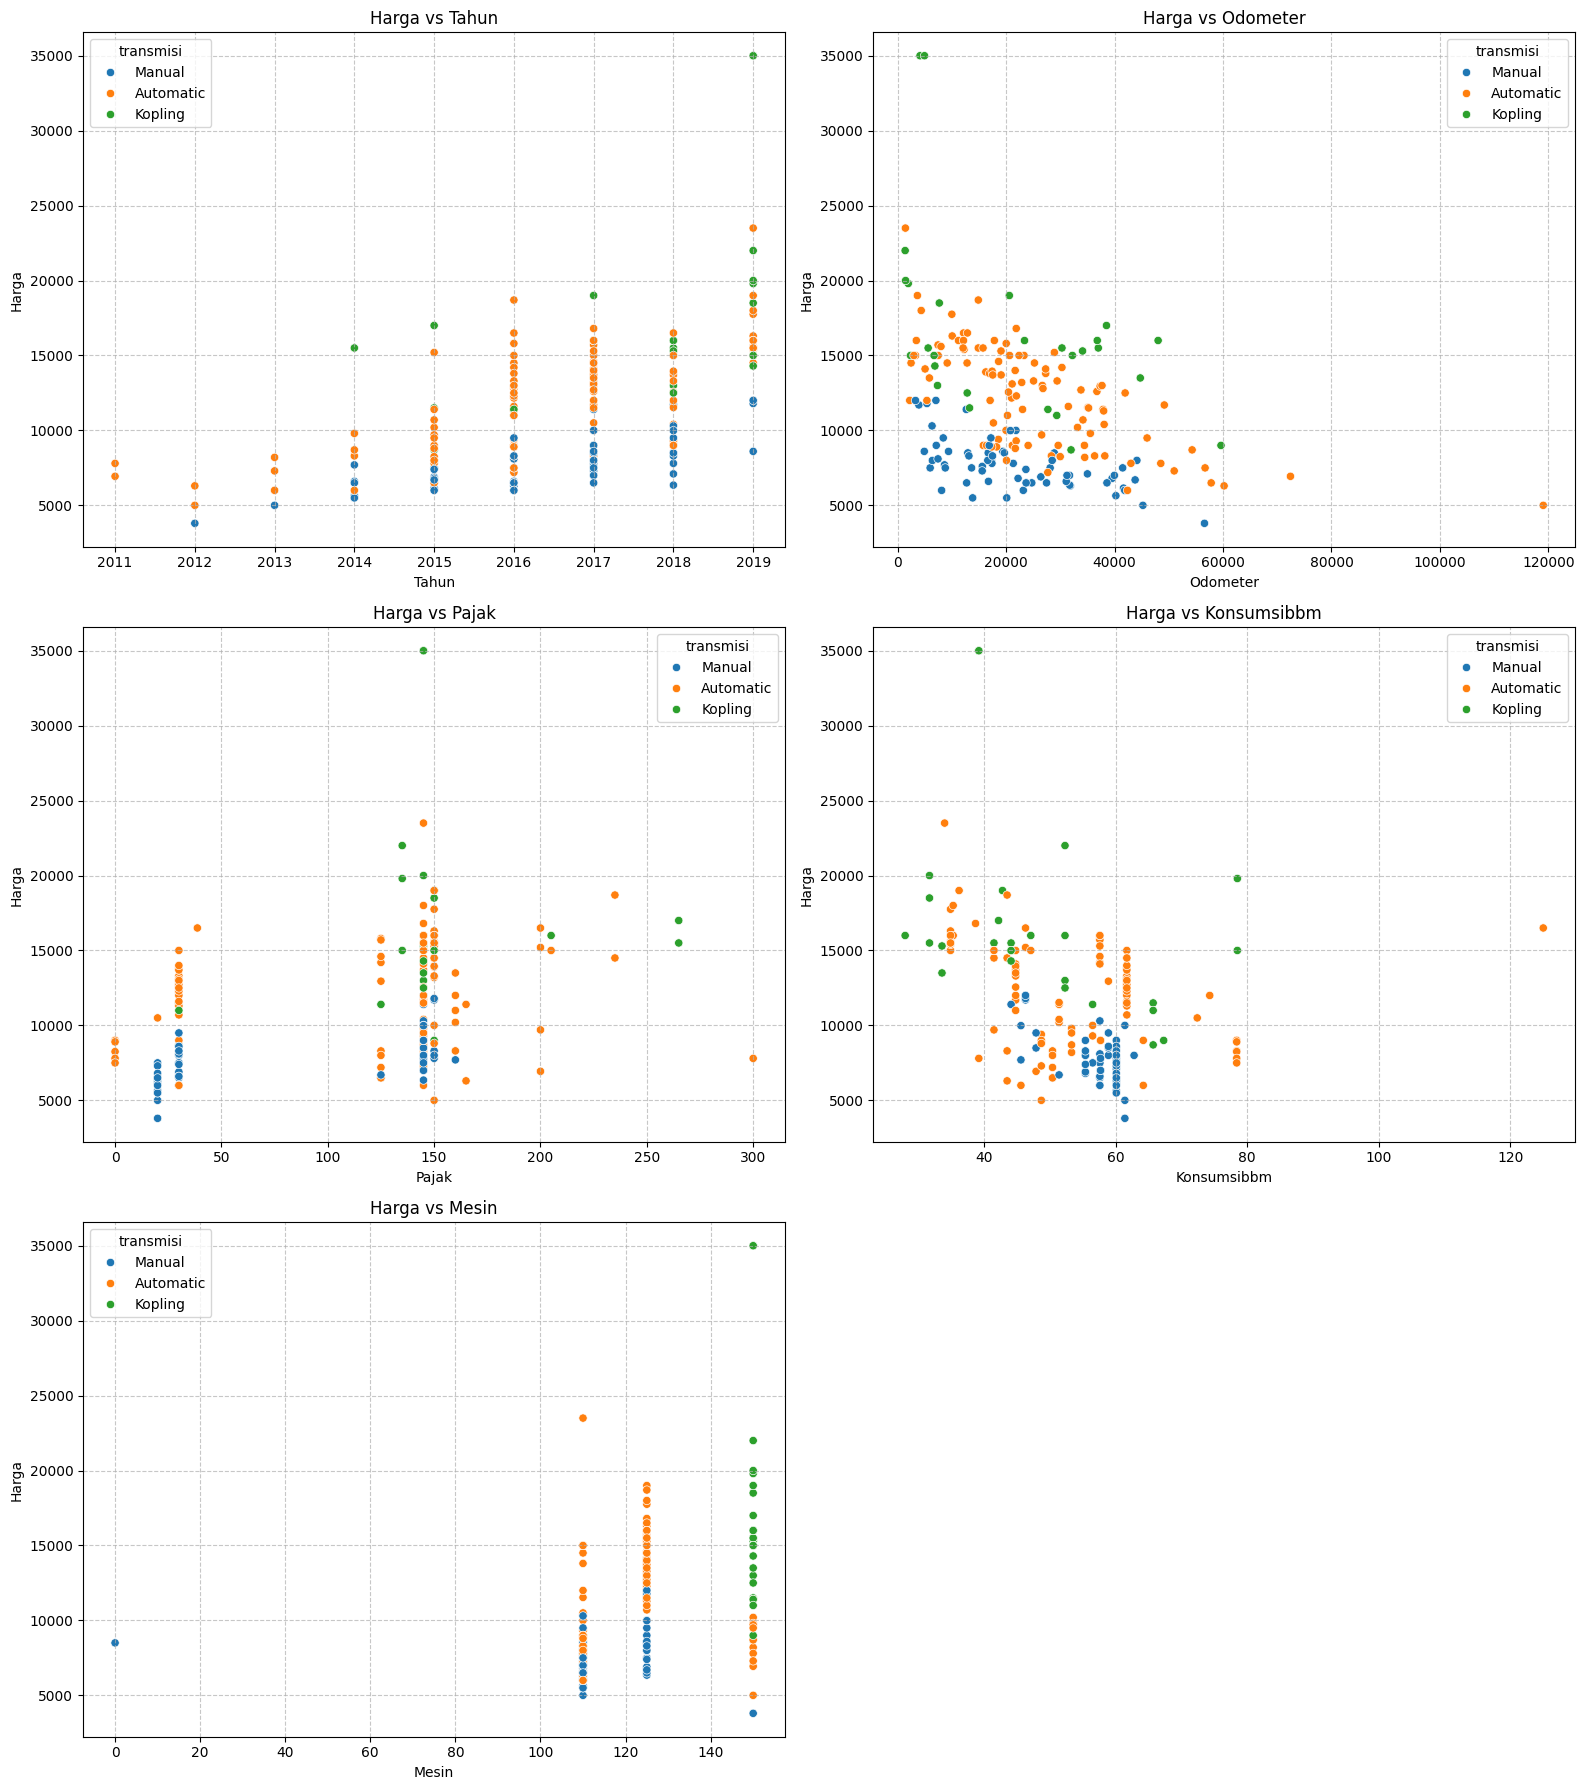

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

# List of columns to plot against 'harga'
columns_to_plot = ['tahun', 'odometer', 'pajak', 'konsumsiBBM', 'mesin']

for i, col in enumerate(columns_to_plot):
    sns.scatterplot(data=df, x=col, y="harga", hue="transmisi", ax=axes[i])
    axes[i].set_title(f'Harga vs {col.replace('_', ' ').title()}')
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Harga')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots if the number of plots is odd
if len(columns_to_plot) % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan scatterplot:
1. Harga vs. Tahun: Terdapat korelasi positif yang jelas. Motor dengan tahun pembuatan yang lebih baru (angka 'tahun' lebih tinggi) cenderung memiliki harga yang lebih tinggi. Ini adalah tren yang wajar karena kendaraan yang lebih baru biasanya lebih mahal.

2. Harga vs. Odometer: Terdapat korelasi negatif. Motor dengan nilai odometer yang lebih rendah (jarak tempuh lebih sedikit) cenderung memiliki harga yang lebih tinggi. Ini juga merupakan tren yang diharapkan, di mana semakin tinggi odometer, semakin rendah harga jual kembali kendaraan.

3. Harga vs. Pajak: Hubungan antara harga dan pajak tidak terlalu linier atau jelas, namun ada kecenderungan harga yang lebih tinggi dikaitkan dengan pajak yang lebih tinggi. Ini mungkin karena pajak seringkali berkorelasi dengan nilai atau spesifikasi kendaraan.

4. Harga vs. Konsumsi BBM: Tampaknya tidak ada korelasi yang sangat kuat antara harga dan konsumsi BBM. Titik-titik data tersebar cukup merata, menunjukkan bahwa konsumsi BBM mungkin bukan faktor utama penentu harga, atau faktor ini saling mengimbangi dengan faktor lain.

5. Harga vs. Mesin: Ada indikasi bahwa motor dengan ukuran mesin yang lebih besar cenderung memiliki harga yang lebih tinggi, meskipun distribusinya tidak sempurna linier. Terdapat beberapa kelompok harga berdasarkan ukuran mesin tertentu.

**Rata-rata Harga Motor Berdasarkan Tahun**

Mounted at /content/drive


/tmp/ipykernel_1228/3663997790.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




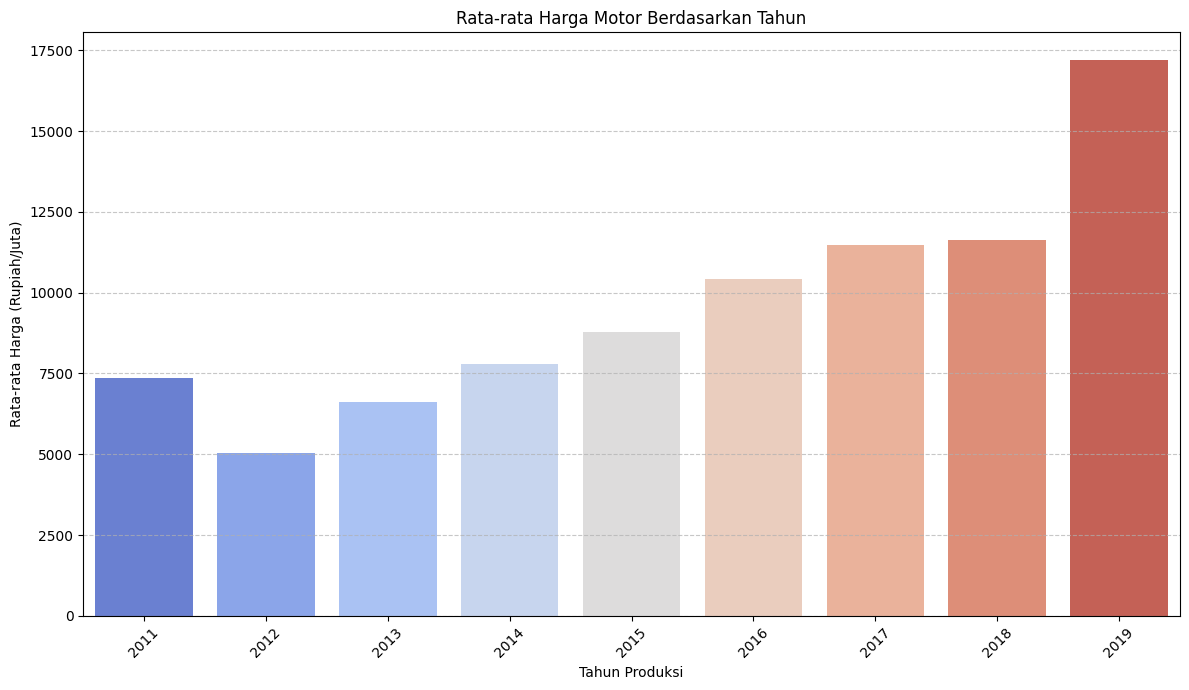

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')

rata_harga_tahun = (
    df.groupby('tahun')['harga']
    .mean()
    .reset_index()
    .sort_values(by='tahun', ascending=True)
)

plt.figure(figsize=(12, 7))
sns.barplot(x='tahun', y='harga', data=rata_harga_tahun, palette='coolwarm')
plt.title('Rata-rata Harga Motor Berdasarkan Tahun')
plt.xlabel('Tahun Produksi')
plt.ylabel('Rata-rata Harga (Rupiah/Juta)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Berdasarkan barchart:

1. Tren Harga Seiring Waktu: dapat dilihat bahwa motor yang lebih baru (tahun produksi yang lebih tinggi) memiliki harga rata-rata yang lebih tinggi. Ini adalah pola yang sangat umum di pasar kendaraan bermotor, di mana usia kendaraan menjadi faktor utama penentu harga.
2. Perbandingan Antar Tahun: membandingkan rata-rata harga antara tahun-tahun yang berbeda. Misalnya, melihat berapa selisih rata-rata harga motor dari tahun 2017 ke 2018, dan seterusnya.

In [ ]:
rata_harga_tahun = (
    df.groupby('tahun')['harga']
    .mean()
    .reset_index()
    .sort_values(by='tahun', ascending=False)
)

# Mengubah nama kolom
rata_harga_tahun.columns = ['Tahun Kendaraan', 'Harga Rata-rata']

print(rata_harga_tahun)

   Tahun Kendaraan  Harga Rata-rata
8             2019     17193.677419
7             2018     11627.193548
6             2017     11479.080000
5             2016     10431.000000
4             2015      8787.461538
3             2014      7794.545455
2             2013      6624.500000
1             2012      5033.000000
0             2011      7367.500000


**Harga Motor Berdasarkan Jenis Transmisi**

Mounted at /content/drive


/tmp/ipykernel_1228/473933842.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




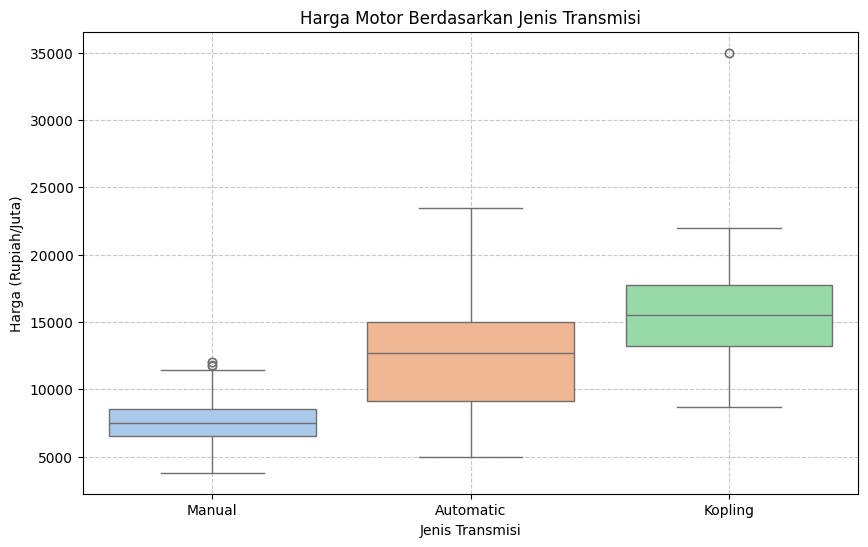

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(x='transmisi', y='harga', data=df, palette='pastel')
plt.title('Harga Motor Berdasarkan Jenis Transmisi')
plt.xlabel('Jenis Transmisi')
plt.ylabel('Harga (Rupiah/Juta)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Berdasarkan boxplot:

**Transmisi Manual dimana:**
1. Harga motor manual relatif rendah dibanding jenis transmisi lainnya.
2. Sebagian besar harga berada pada rentang Rp6,5–8,5 juta.
3. Median sekitar Rp7,5 juta, menunjukkan 50% motor manual memiliki harga di bawah nilai tersebut.
4. Terdapat beberapa outlier di sekitar Rp12 juta yang kemungkinan merupakan motor manual dengan tahun lebih baru atau kondisi lebih baik.

**Transmisi Automatic dimana:**
1. Harga motor automatic jauh lebih tinggi dibanding motor manual.
2. Sebagian besar harga berada pada rentang Rp9–15 juta.
3. Median sekitar Rp12,7 juta.
4. Sebaran data cukup lebar sekitar Rp6 juta yang menunjukkan variasi harga cukup besar.
5. Tidak terlihat outlier yang ekstrem sehingga distribusi harga masih cukup konsisten.

**Transmisi Kopling dimana:**
1. Motor kopling memiliki median harga tertinggi.
Sebagian besar harga berada pada rentang Rp13–18 juta.
2. Terdapat satu outlier sangat tinggi sekitar Rp35 juta yang kemungkinan berasal dari motor sport premium atau trail (misalnya CB150R atau CRF150).
3. Variasi harga cukup besar karena mencakup beberapa segmen motor sport.


**Pengaruh Jenis Motor terhadap Harga**

Mounted at /content/drive


/tmp/ipykernel_1228/4029448432.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




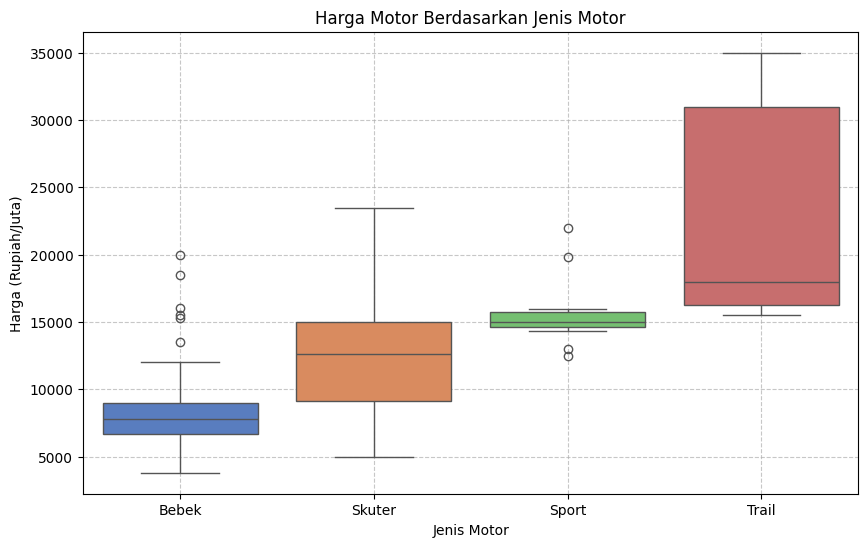

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/motor_second.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(x='jenis', y='harga', data=df, palette='muted')
plt.title('Harga Motor Berdasarkan Jenis Motor')
plt.xlabel('Jenis Motor')
plt.ylabel('Harga (Rupiah/Juta)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Berdasarkan boxplot:

**Motor Bebek dimana:**
1. Motor bebek memiliki harga paling rendah dibanding kategori lain.
2. Sebagian besar harga berada pada rentang Rp6,5–8,8 juta.
3. Median sekitar Rp7,7 juta, artinya 50% data berada di bawah harga tersebut.
4. Terdapat beberapa outlier di atas Rp13 juta yang kemungkinan merupakan unit dengan tahun lebih baru atau kondisi sangat baik.

**Motor Skuter (Matic) dimana:**
1. Skuter memiliki harga yang lebih tinggi dibanding motor bebek.
2. Rentang harga cukup lebar, menunjukkan variasi model yang beragam.
3. Median sekitar Rp12,7 juta.
Sebagian besar harga berada pada rentang Rp9–15 juta.

**Motor Sport dimana:**
1. Harga motor sport relatif tinggi dan cukup seragam.
2. Sebagian besar unit berada pada rentang Rp14,5–16 juta.
3. Box sangat sempit, menunjukkan variasi harga yang kecil.
4. Terdapat beberapa outlier yang kemungkinan berasal dari:
*   Unit lebih tua (harga lebih rendah)
*   Unit lebih baru atau kondisi premium (harga lebih tinggi)

**Motor Trail dimana:**
1. Motor trail merupakan kategori dengan harga tertinggi.
2. Median sekitar Rp18 juta.
3. Rentang harga sangat lebar.
4. Sebagian besar unit berada antara Rp16–31 juta.
5. Harga maksimum mencapai sekitar Rp35 juta.

Mounted at /content/drive


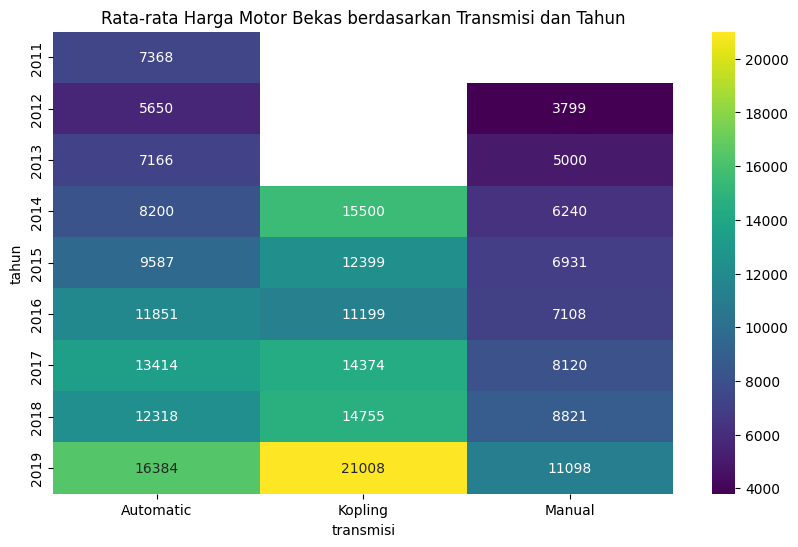

In [ ]:
drive.mount('/content/drive', force_remount=True)

# 1. Load data with the correct path and separator
df = pd.read_csv('/content/drive/MyDrive/motor_second.csv', sep=',')

# 2. Buat tabel pivot (agregasi rata-rata harga)
pivot_table = df.pivot_table(values='harga', index='tahun', columns='transmisi', aggfunc='mean')

# 3. Gambar Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='viridis')
plt.title('Rata-rata Harga Motor Bekas berdasarkan Transmisi dan Tahun')
plt.show()

Berdasarkan gambar di atas:
1. Kendaraan transmisi kopling keluaran tahun 2019 adalah rata-rata harga motor tertinggi dari yang lainya.
2. Kendaraan transmisi manual keluaran tahun 2012 adalah rata-rata harga motor terendah dari yang lainya.
3. Kendaraan transmisi automatic adalah motor dengan distribusi harga paling konsisten dari yang lainya.
